<a href="https://colab.research.google.com/github/Emyfoton/Codigos_pregrado/blob/main/Datos_Efecto_Hall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Actividad 1

In [ ]:
B= np.array([15.2, 22, 29.7, 36.6, 44.9, 51.7, 59.8, 69.2, 76.8, 84.7]) #y
I= np.array([0.04, 0.08, 0.12, 0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4]) #x
errorI= 0.01 * np.ones_like(I)
errorB= 0.1 * np.ones_like(B)


Text(0.5, 1.0, 'Caracterización Campo Magnético')

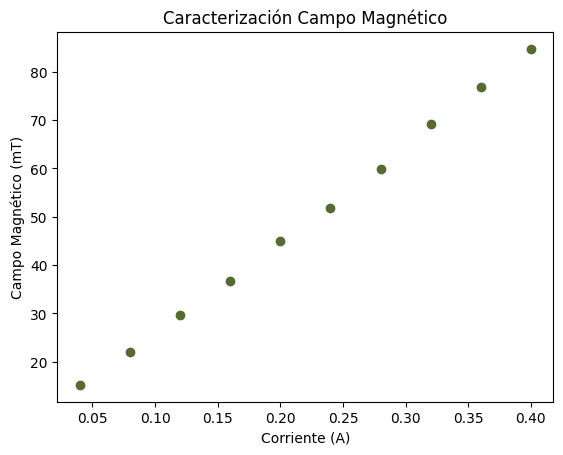

In [ ]:
plt.scatter(I, B, c="darkolivegreen")
plt.xlabel("Corriente (A)")
plt.ylabel("Campo Magnético (mT)")
plt.title("Caracterización Campo Magnético")

Slope: 194.39393941384603 ± 0.2752409452638484
Intercept: 6.293333326224041 ± 0.06831300554397919
Residuals: [ 11.30909097   1.55151521   0.79393944  -7.96363632  -2.72121209
 -12.47878786  -9.23636362   7.00606061   5.24848485   6.49090908]


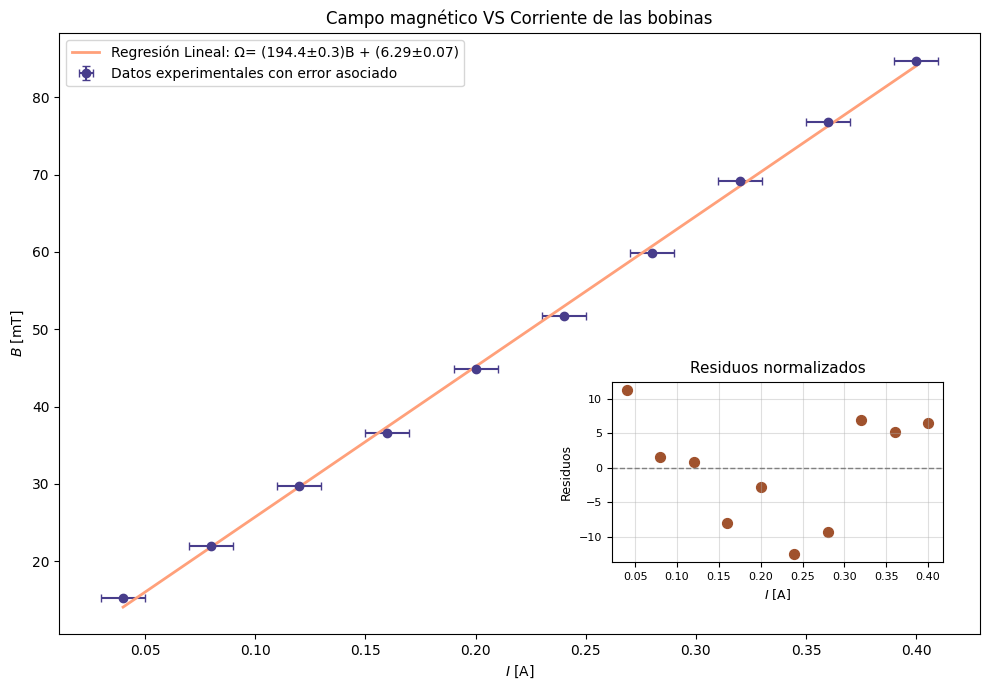

In [ ]:
def linear_function(X, a, b):
    return a * X + b

x1=I
y1=B
errorx1= errorB
errory1=errorI
popt, pcov = curve_fit(
    linear_function,
    x1,
    y1,
    sigma=errorx1,
    absolute_sigma=True
)
slope = popt[0]
intercept = popt[1]
slope_std_err = np.sqrt(pcov[0, 0])
intercept_std_err = np.sqrt(pcov[1, 1])
yerr = errorx1
xerr = errory1
Y_pred = linear_function(x1, *popt)
residuals = (y1 - Y_pred) / yerr


print(f"Slope: {slope} ± {slope_std_err}")
print(f"Intercept: {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")


# =====================================
# MAIN FIGURE
# =====================================

fig, ax1 = plt.subplots(figsize=(10, 7))

ax1.errorbar(
    x1,
    y1,
    yerr=yerr,
    xerr=xerr,
    fmt='o',
    c="darkslateblue",
    label='Datos experimentales con error asociado',
    capsize=3
)

ax1.plot(
    x1,
    Y_pred,
    color='lightsalmon',
    linewidth=2,
    label=(
        f'Regresión Lineal: '
        f'Ω= ({slope:.1f}±{slope_std_err:.1f})B + '
        f'({intercept:.2f}±{intercept_std_err:.2f})'
    )
)
ax1.set_xlabel(r'$I$ [A]')
ax1.set_ylabel(r'$B$ [mT]')

ax1.set_title(
    'Campo magnético VS Corriente de las bobinas'
)

ax1.legend(loc='upper left')


# =====================================
# RESIDUALS INSET
# =====================================

ax_res = ax1.inset_axes(
    [0.60, 0.12, 0.36, 0.30]
)
ax_res.scatter(
    x1,
    residuals,
    color='sienna',
    s=50
)
ax_res.axhline(
    0,
    color='grey',
    linewidth=1,
    linestyle='--'
)



ax_res.set_title(
    'Residuos normalizados',
    fontsize=11
)

ax_res.set_xlabel(
    r'$I$ [A]',
    fontsize=9
)

ax_res.set_ylabel(
    r'Residuos',
    fontsize=9
)

ax_res.tick_params(
    axis='both',
    labelsize=8
)

ax_res.grid(
    True,
    alpha=0.4
)

plt.tight_layout()
plt.show()

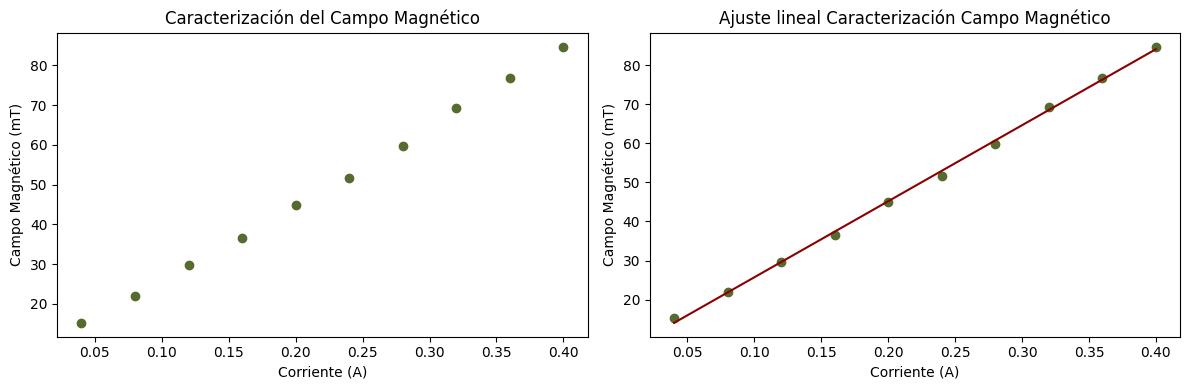

In [ ]:
fig,ax= plt.subplots(1,2, figsize=(12,4))

ax[0].scatter(I,B, c="darkolivegreen")
ax[0].set_xlabel("Corriente (A)")
ax[0].set_ylabel("Campo Magnético (mT)")
ax[0].set_title("Caracterización del Campo Magnético")

ax[1].scatter(x1, y1, c="darkolivegreen") # Original data as scatter points
ax[1].plot(x1, Y_pred, color='darkred') # Linear regression as a line
ax[1].set_xlabel("Corriente (A)")
ax[1].set_ylabel("Campo Magnético (mT)")
ax[1].set_title("Ajuste lineal Caracterización Campo Magnético")

plt.tight_layout()
plt.show()

In [ ]:
B = 194*(-0.032) + 6.29
B


0.08199999999999985

In [ ]:
slope

np.float64(194.39393941384603)

# Actividad 2 p-Ge y n-Ge

Placa p-Ge
###
B constante variando I
###
5 tomas

In [ ]:
from cycler import V
#B 200mT (1A)
V_L11= np.array([1.07, 0.76,0.58, 0.26,0.08, -0.15,-0.48, -0.67,-0.97]) #V
V_H11= np.array([46.3, 32.5,24.4, 11.4, 5.1, -6.2,-21.2, -27.9,-41.5]) #mV
I_p11= np.array([-30, -20,-15, -5,0, 5,15, 20,30])

#B 180mT (0.9A)
V_L21= np.array([1.09, 0.74,0.58, 0.23,0.05, -0.13,-0.49, -0.66,-1])
V_H21= np.array([43.5, 29.5,21.9, 9.5,3.7, -5,-19.0, -25.4,-40.2]) #mV
I_p21= np.array([-30, -20,-15, -5,0, 5,15, 20, 30])

#B 160mT (0.8A)
V_L31= np.array([1.07, 0.74,0.57, 0.21,0.05, -0.15,-0.48, -0.65,-1.01])
V_H31= np.array([39, 27.7,21.0, 8.1,2.4, -5.2,-17, -23.7,-36])
I_p31= np.array([-30, -20,-15, -5,0, 5,15, 20,30])

#B 220mT (1.1A)
V_L41= np.array([1.13, 0.75,0.58, 0.23,0.07, -0.15,-0.49, -0.67,-0.99])
V_H41= np.array([50.7, 34.0, 26.4, 10.7,3.7, -6.4,-21.8, -29.7,-44])
I_p41= np.array([-30, -20,-15, -5 ,0, 5,15, 20,30])

#B 240mT (1.2A)
V_L51= np.array([1.09, 0.77,0.57, 0.25 ,0.04, -0.15 ,-0.49, -0.67, -1.04])
V_H51= np.array([52.1, 36.6, 27.3, 12.3 , 2.4,-6.7 ,-23.1, -31.1, -49])
I_p51= np.array([-30, -20,-15, -5, 0, 5,15, 20 ,30])

In [ ]:
Vhs = [V_H11, V_H21, V_H31, V_H41, V_H51]
slopes = []
slope_errs = []
inters = []
inter_errs = []
norm_res = []
y_preds = []
Bs = [200, 180, 160, 220, 240]
Berrs = np.ones_like(Bs)

for i in range(len(Vhs)):
  x = I_p11
  y = Vhs[i]
  yerr = np.ones_like(y)*0.1
  xerr = np.ones_like(x)
  weights = 1 / yerr**2

  # Calculate sums needed for slope and intercept
  sum_w = weights.sum()
  sum_wx = (weights * x).sum()
  sum_wy = (weights * y).sum()
  sum_wxx = (weights * x**2).sum()
  sum_wxy = (weights * x * y).sum()

  # Calculate weighted slope (a) and intercept (b)
  slope = (sum_w * sum_wxy - sum_wx * sum_wy) / (sum_w * sum_wxx - sum_wx**2)
  intercept = (sum_wxx * sum_wy - sum_wx * sum_wxy) / (sum_w * sum_wxx - sum_wx**2)

  # Calculate standard errors (uncertainties)
  slope_std_err = np.sqrt(sum_w / (sum_w * sum_wxx - sum_wx**2))
  intercept_std_err = np.sqrt(sum_wxx / (sum_w * sum_wxx - sum_wx**2))

  # Predict the Y values
  y_pred = slope * x + intercept

  # Calculate normalized residuals
  residuals = (y - y_pred)/yerr

  slopes.append(slope)
  slope_errs.append(slope_std_err)
  inters.append(intercept)
  inter_errs.append(intercept_std_err)
  norm_res.append(residuals)
  y_preds.append(y_pred)

Text(0.5, 1.0, 'p-Ge B cte I variable')

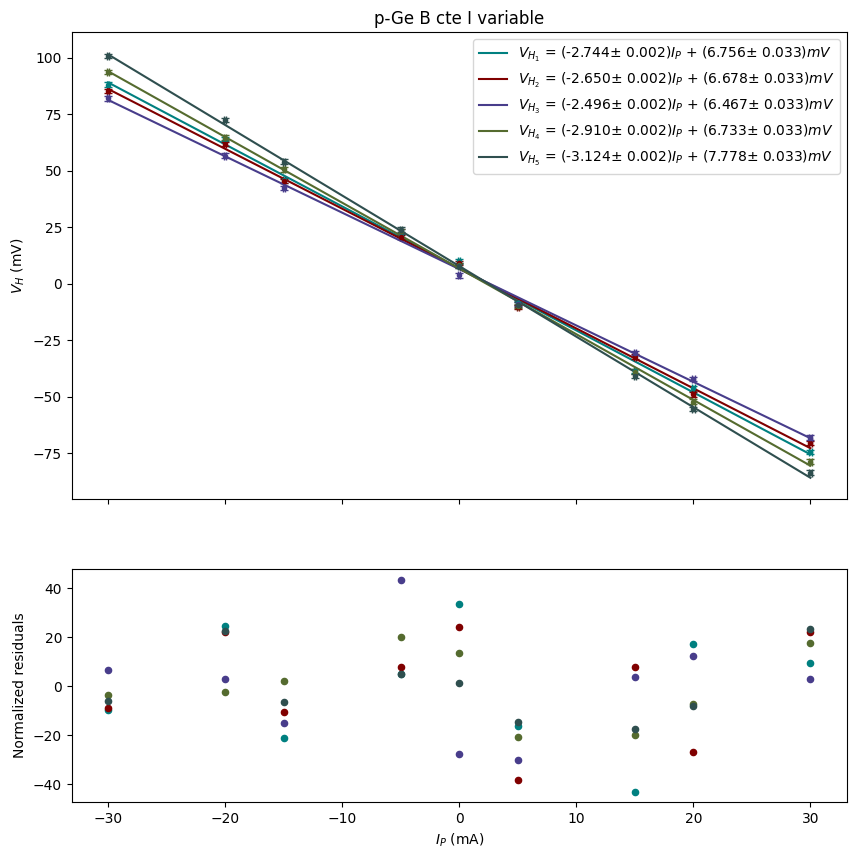

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex = True)
axes[0].errorbar(I_p11, V_H11, np.ones_like(I_p11), np.ones_like(V_H11)*0.1, c="teal", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[0], c = 'teal', label = f'$V_{{H_1}}$ = ({slopes[0]:.3f}± {slope_errs[0]:.3f})$I_P$ + ({inters[0]:.3f}± {inter_errs[0]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[0], c = 'teal', label = 'Residuos toma 1', s = 20)

axes[0].errorbar(I_p21, V_H21, np.ones_like(I_p21), np.ones_like(V_H21)*0.1, c="maroon", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[1], c = 'maroon', label = f'$V_{{H_2}}$ = ({slopes[1]:.3f}± {slope_errs[1]:.3f})$I_P$ + ({inters[1]:.3f}± {inter_errs[1]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[1], c = 'maroon', label = 'Residuos toma 2', s = 20)

axes[0].errorbar(I_p21, V_H31, np.ones_like(I_p21), np.ones_like(V_H21)*0.1, c="darkslateblue", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[2], c = 'darkslateblue', label = f'$V_{{H_3}}$ = ({slopes[2]:.3f}± {slope_errs[2]:.3f})$I_P$ + ({inters[2]:.3f}± {inter_errs[2]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[2], c = 'darkslateblue', label = 'Residuos toma 3', s = 20)

axes[0].errorbar(I_p21, V_H41, np.ones_like(I_p21), np.ones_like(V_H21)*0.1, c="darkolivegreen", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[3], c = 'darkolivegreen', label = f'$V_{{H_4}}$ = ({slopes[3]:.3f}± {slope_errs[3]:.3f})$I_P$ + ({inters[3]:.3f}± {inter_errs[3]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[3], c = 'darkolivegreen', label = 'Residuos toma 4', s = 20)

axes[0].errorbar(I_p21, V_H51, np.ones_like(I_p21), np.ones_like(V_H21)*0.1, c="darkslategray", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[4], c = 'darkslategray', label = f'$V_{{H_5}}$ = ({slopes[4]:.3f}± {slope_errs[4]:.3f})$I_P$ + ({inters[4]:.3f}± {inter_errs[4]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[4], c = 'darkslategray', label = 'Residuos toma 5', s = 20)

axes[1].set_xlabel(r"$I_P$ (mA)")
axes[0].set_ylabel(r"$V_H$ (mV)")
axes[1].set_ylabel("Normalized residuals")
axes[0].legend(loc = 'best')
axes[0].set_title("p-Ge B cte I variable")

In [ ]:
import numpy as np

# --- Datos de la leyenda ---
m   = np.array([-1.488, -1.385, -1.263, -1.588, -1.690])  # Ω = mV/mA
m_e = np.array([ 0.002,  0.002,  0.002,  0.002,  0.002])  # Ω
b   = np.array([ 2.544,  2.056,  1.811,  2.622,  2.311])  # mV
b_e = np.array([ 0.033,  0.033,  0.033,  0.033,  0.033])  # mV

# --- Campos magnéticos (en T) ---
B = np.array([0.200, 0.180, 0.160, 0.220, 0.240])         # T

# --- Espesor de la muestra (AJUSTA a tu valor real) ---
d = 1e-3   # m

# --- Constantes ---
q = 1.602e-19  # C

# --- Coeficiente Hall ---
R_H     = m * d / B
R_H_err = m_e * d / B

# --- Concentración de portadores ---
p     = 1 / (R_H * q)
p_err = p * (R_H_err / np.abs(R_H))

# --- Reporte ---
print(f"{'Curva':<8}{'B (T)':<8}{'R_H (m³/C)':<24}{'p (cm⁻³)':<24}")
for i in range(5):
    print(f"H_{i+1:<5}{B[i]:<8.3f}"
          f"{R_H[i]:>10.4e} ± {R_H_err[i]:.1e}   "
          f"{p[i]/1e6:>10.3e} ± {p_err[i]/1e6:.1e}")

Curva   B (T)   R_H (m³/C)              p (cm⁻³)                
H_1    0.200   -7.4400e-03 ± 1.0e-05   -8.390e+14 ± -1.1e+12
H_2    0.180   -7.6944e-03 ± 1.1e-05   -8.113e+14 ± -1.2e+12
H_3    0.160   -7.8937e-03 ± 1.2e-05   -7.908e+14 ± -1.3e+12
H_4    0.220   -7.2182e-03 ± 9.1e-06   -8.648e+14 ± -1.1e+12
H_5    0.240   -7.0417e-03 ± 8.3e-06   -8.865e+14 ± -1.0e+12


Placa n-Ge
###
B constante variando I
###
5 tomas

In [ ]:
#B 200mT (1A)
V_L11= np.array([1.18, 0.85, 0.59, 0.25, 0.10, -0.15, -0.57, -0.67, -1.06]) #V
V_H11= np.array([88.1, 64.1, 45.8, 21.0, 10.1, -8.6, -38.7, -46.4, -74.6]) #mV
I_p11= np.array([-30, -20 ,-15, -5, 0, 5, 15, 20, 30]) #mA

#B 180mT (0.9A)
V_L21= np.array([1.20, 0.86, 0.62, 0.26, 0.09, -0.18, -0.5, -0.75, -1.06]) #V
V_H21= np.array([85.3, 61.9, 45.4, 20.7, 9.1, -10.4, -32.3, -49, -70.6]) #mV
I_p21= np.array([-30, -20 ,-15, -5, 0, 5, 15, 20, 30]) #mA

#B 160mT (0.8A)
V_L31= np.array([1.22, 0.83, 0.61,0.32, 0.01, -0.17, -0.51, -0.68, -1.08]) #V
V_H31= np.array([82, 56.7, 42.4, 23.3, 3.7, -9, -30.6, -42.2, -68.1]) #mV
I_p31= np.array([-30, -20 ,-15, -5, 0, 5, 15, 20, 30]) #mA

#B 220mT (1.1A)
V_L41= np.array([1.20, 0.82, 0.63, 0.27, 0.07, -0.16, -0.54, -0.72, -1.07]) #V
V_H41= np.array([93.7, 64.7, 50.6, 23.3, 8.1, -9.9, -38.9, -52.2, -78.8]) #mV
I_p41= np.array([-30, -20 ,-15, -5, 0, 5, 15, 20, 30]) #mA

#B 240mT (1.2A)
V_L51= np.array([1.23, 0.87, 0.64, 0.26, 0.06,-0.15, -0.54, -0.72, -1.08]) #V
V_H51= np.array([100.9, 72.5, 54.0, 23.9, 7.9,-9.3, -40.8, -55.5, -83.6]) #mV
I_p51= np.array([-30, -20 ,-15, -5, 0, 5, 15, 20, 30]) #mA

In [ ]:
Vhs = [V_H11, V_H21, V_H31, V_H41, V_H51]
slopes = []
slope_errs = []
inters = []
inter_errs = []
norm_res = []
y_preds = []

for i in range(len(Vhs)):
  x = I_p11
  y = Vhs[i]
  yerr = np.ones_like(y)*0.1
  xerr = np.ones_like(x)
  weights = 1 / yerr**2

  # Calculate sums needed for slope and intercept
  sum_w = weights.sum()
  sum_wx = (weights * x).sum()
  sum_wy = (weights * y).sum()
  sum_wxx = (weights * x**2).sum()
  sum_wxy = (weights * x * y).sum()

  # Calculate weighted slope (a) and intercept (b)
  slope = (sum_w * sum_wxy - sum_wx * sum_wy) / (sum_w * sum_wxx - sum_wx**2)
  intercept = (sum_wxx * sum_wy - sum_wx * sum_wxy) / (sum_w * sum_wxx - sum_wx**2)

  # Calculate standard errors (uncertainties)
  slope_std_err = np.sqrt(sum_w / (sum_w * sum_wxx - sum_wx**2))
  intercept_std_err = np.sqrt(sum_wxx / (sum_w * sum_wxx - sum_wx**2))

  # Predict the Y values
  y_pred = slope * x + intercept

  # Calculate normalized residuals
  residuals = (y - y_pred)/yerr

  slopes.append(slope)
  slope_errs.append(slope_std_err)
  inters.append(intercept)
  inter_errs.append(intercept_std_err)
  norm_res.append(residuals)
  y_preds.append(y_pred)

Text(0.5, 1.0, 'n-Ge B cte I variable')

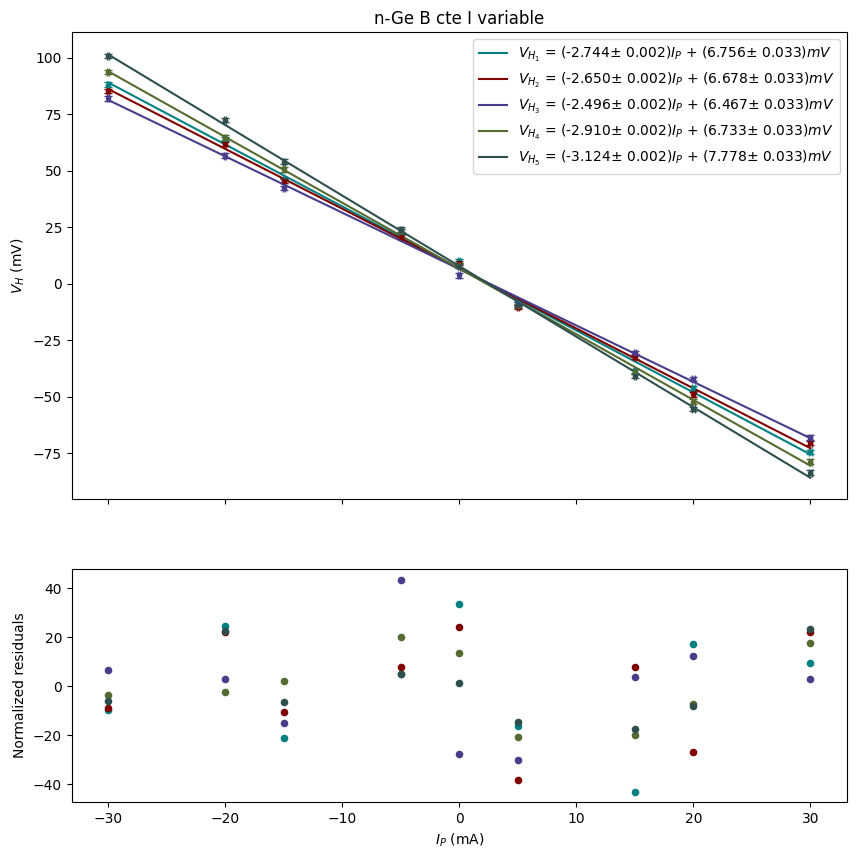

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex = True)

axes[0].errorbar(I_p11, V_H11, np.ones_like(I_p11), np.ones_like(V_H11)*0.1, c="teal", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[0], c = 'teal', label = f'$V_{{H_1}}$ = ({slopes[0]:.3f}± {slope_errs[0]:.3f})$I_P$ + ({inters[0]:.3f}± {inter_errs[0]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[0], c = 'teal', label = 'Residuos toma 1', s = 20)

axes[0].errorbar(I_p21, V_H21, np.ones_like(I_p21), np.ones_like(V_H21)*0.1, c="maroon", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[1], c = 'maroon', label = f'$V_{{H_2}}$ = ({slopes[1]:.3f}± {slope_errs[1]:.3f})$I_P$ + ({inters[1]:.3f}± {inter_errs[1]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[1], c = 'maroon', label = 'Residuos toma 2', s = 20)

axes[0].errorbar(I_p21, V_H31, np.ones_like(I_p21), np.ones_like(V_H21)*0.1, c="darkslateblue", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[2], c = 'darkslateblue', label = f'$V_{{H_3}}$ = ({slopes[2]:.3f}± {slope_errs[2]:.3f})$I_P$ + ({inters[2]:.3f}± {inter_errs[2]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[2], c = 'darkslateblue', label = 'Residuos toma 3', s = 20)

axes[0].errorbar(I_p21, V_H41, np.ones_like(I_p21), np.ones_like(V_H21)*0.1, c="darkolivegreen", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[3], c = 'darkolivegreen', label = f'$V_{{H_4}}$ = ({slopes[3]:.3f}± {slope_errs[3]:.3f})$I_P$ + ({inters[3]:.3f}± {inter_errs[3]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[3], c = 'darkolivegreen', label = 'Residuos toma 4', s = 20)

axes[0].errorbar(I_p21, V_H51, np.ones_like(I_p21), np.ones_like(V_H21)*0.1, c="darkslategray", fmt='o', capsize=3, ms = 3)
axes[0].plot(I_p11, y_preds[4], c = 'darkslategray', label = f'$V_{{H_5}}$ = ({slopes[4]:.3f}± {slope_errs[4]:.3f})$I_P$ + ({inters[4]:.3f}± {inter_errs[4]:.3f})$mV$')
axes[1].scatter(I_p11, norm_res[4], c = 'darkslategray', label = 'Residuos toma 5', s = 20)

axes[1].set_xlabel(r"$I_P$ (mA)")
axes[0].set_ylabel(r"$V_H$ (mV)")
axes[1].set_ylabel("Normalized residuals")
axes[0].legend(loc = 'best')
axes[0].set_title("n-Ge B cte I variable")

In [ ]:
import numpy as np

# Datos n-Ge (B constante, I variable)
m   = np.array([-2.744, -2.650, -2.496, -2.910, -3.124])   # Ω = mV/mA
m_e = np.array([ 0.002,  0.002,  0.002,  0.002,  0.002])
b   = np.array([ 6.756,  6.678,  6.467,  6.733,  7.778])   # mV
b_e = np.array([ 0.033,  0.033,  0.033,  0.033,  0.033])

B = np.array([0.200, 0.180, 0.160, 0.220, 0.240])          # T

d = 1e-3          # m  ← AJUSTA al espesor real
q = 1.602e-19     # C

# Coeficiente Hall
R_H     = m * d / B
R_H_err = m_e * d / B

# Concentración de portadores
n     = 1 / (R_H * q)
n_err = np.abs(n) * (R_H_err / np.abs(R_H))

print("Curva | B (T) | R_H (m³/C)            | n (cm⁻³)")
print("-"*65)
for i in range(5):
    print(f"H_{i+1}  | {B[i]:.3f} | {R_H[i]:.4e} ± {R_H_err[i]:.0e} | "
          f"{n[i]/1e6:.3e} ± {n_err[i]/1e6:.0e}")

# Promedio ponderado
w = 1/R_H_err**2
R_H_avg = np.sum(R_H*w)/np.sum(w)
R_H_avg_err = np.sqrt(1/np.sum(w))
n_avg = 1/(R_H_avg*q)
n_avg_err = np.abs(n_avg)*(R_H_avg_err/np.abs(R_H_avg))

print(f"\nR_H promedio = {R_H_avg:.4e} ± {R_H_avg_err:.0e} m³/C")
print(f"n promedio   = {n_avg/1e6:.3e} ± {n_avg_err/1e6:.0e} cm⁻³")

Curva | B (T) | R_H (m³/C)            | n (cm⁻³)
-----------------------------------------------------------------
H_1  | 0.200 | -1.3720e-02 ± 1e-05 | -4.550e+14 ± 3e+11
H_2  | 0.180 | -1.4722e-02 ± 1e-05 | -4.240e+14 ± 3e+11
H_3  | 0.160 | -1.5600e-02 ± 1e-05 | -4.001e+14 ± 3e+11
H_4  | 0.220 | -1.3227e-02 ± 9e-06 | -4.719e+14 ± 3e+11
H_5  | 0.240 | -1.3017e-02 ± 8e-06 | -4.796e+14 ± 3e+11

R_H promedio = -1.3800e-02 ± 4e-06 m³/C
n promedio   = -4.523e+14 ± 1e+11 cm⁻³


Placa p-Ge
###
I constante variando B
###
5 tomas

In [ ]:
def I(B):
  return 0.005138408623234669*B - 0.03
B= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

print(I(B))
I= I(B)

[0.79214538 0.84352947 0.89491355 0.94629764 0.99768172 1.04906581
 1.1004499  1.15183398 1.20321807 1.25460216]


In [ ]:
#propagación de error B
sigma_B= np.sqrt(((0.28*I)**2+(194.4*0.01)**2+0.07**2))
print(np.round(sigma_B,2))

[1.96 1.96 1.96 1.96 1.97 1.97 1.97 1.97 1.97 1.98]


In [ ]:
#-30mA
V_L12= np.array([1.08, 1.08, 1.09, 1.09, 1.09, 1.09, 1.09, 1.09, 1.09, 1.09])
V_H12= np.array([39.2, 40.6, 42.4, 44.0, 45.3, 46.7, 48.4, 49.7, 51.2, 52.6])
B1= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

#-15mA
V_L22= np.array([0.58, 0.58, 0.58, 0.58, 0.58, 0.59, 0.59, 0.59, 0.59, 0.59])
V_H22= np.array([22.4, 23.1, 23.8, 24.7, 25.5, 26.3, 27.1, 27.6, 27.9, 28.6])
B2= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

#0mA
V_L32= np.array([0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04, 0.04])
V_H32= np.array([1.9,  1.9,  2.0,  2.1,  2.2,  2.3,  2.4,  2.4,  2.5,  2.5])
B3= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

#15mA
V_L42= np.array([-0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5, -0.5])
V_H42= np.array([-18.7, -19.2, -19.8, -20.4, -21.1, -21.7, -22,-22.6 ,-23.1, -23.7])
B4= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

#30mA
V_L52= np.array([-1.05, -1.05, -1.05, -1.06, -1.06, -1.06, -1.06 , -1.06, -1.06, -1.06])
V_H52 = np.array([-39.1,-40.5, -41.8, -43.4, -44.7, -45, -46, -47.6, -49, -50.2])
B5= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

In [ ]:
Vhs = [V_H12, V_H22, V_H32, V_H42, V_H52]
slopes = []
slope_errs = []
inters = []
inter_errs = []
norm_res = []
y_preds = []

for i in range(len(Vhs)):
  x = B1
  y = Vhs[i]
  yerr = np.ones_like(y)*0.1
  xerr = np.ones_like(x)
  weights = 1 / yerr**2

  # Calculate sums needed for slope and intercept
  sum_w = weights.sum()
  sum_wx = (weights * x).sum()
  sum_wy = (weights * y).sum()
  sum_wxx = (weights * x**2).sum()
  sum_wxy = (weights * x * y).sum()

  # Calculate weighted slope (a) and intercept (b)
  slope = (sum_w * sum_wxy - sum_wx * sum_wy) / (sum_w * sum_wxx - sum_wx**2)
  intercept = (sum_wxx * sum_wy - sum_wx * sum_wxy) / (sum_w * sum_wxx - sum_wx**2)

  # Calculate standard errors (uncertainties)
  slope_std_err = np.sqrt(sum_w / (sum_w * sum_wxx - sum_wx**2))
  intercept_std_err = np.sqrt(sum_wxx / (sum_w * sum_wxx - sum_wx**2))

  # Predict the Y values
  y_pred = slope * x + intercept

  # Calculate normalized residuals
  residuals = (y - y_pred)/yerr

  slopes.append(slope)
  slope_errs.append(slope_std_err)
  inters.append(intercept)
  inter_errs.append(intercept_std_err)
  norm_res.append(residuals)
  y_preds.append(y_pred)

Text(0.5, 1.0, 'p-Ge I cte B variable')

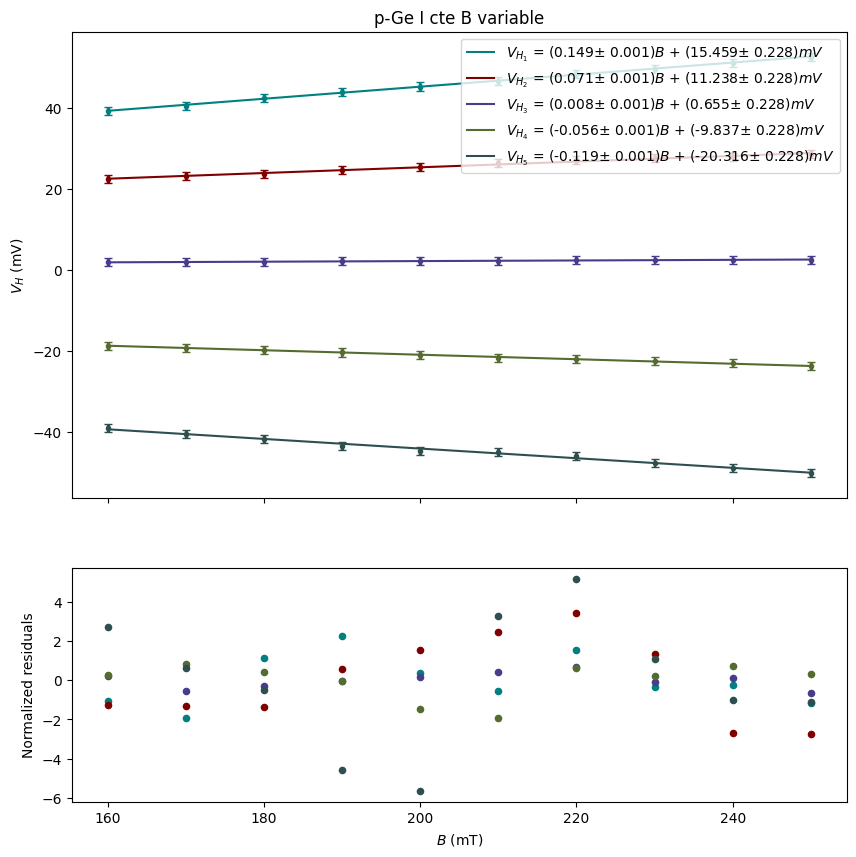

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex = True)
axes[0].errorbar(B1, V_H12, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="teal", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[0], c = 'teal', label = f'$V_{{H_1}}$ = ({slopes[0]:.3f}± {slope_errs[0]:.3f})$B$ + ({inters[0]:.3f}± {inter_errs[0]:.3f})$mV$')
axes[1].scatter(B1, norm_res[0], c = 'teal', label = 'Residuos toma 1', s = 20)

axes[0].errorbar(B1, V_H22, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="maroon", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[1], c = 'maroon', label = f'$V_{{H_2}}$ = ({slopes[1]:.3f}± {slope_errs[1]:.3f})$B$ + ({inters[1]:.3f}± {inter_errs[1]:.3f})$mV$')
axes[1].scatter(B1, norm_res[1], c = 'maroon', label = 'Residuos toma 2', s = 20)

axes[0].errorbar(B1, V_H32, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="darkslateblue", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[2], c = 'darkslateblue', label = f'$V_{{H_3}}$ = ({slopes[2]:.3f}± {slope_errs[2]:.3f})$B$ + ({inters[2]:.3f}± {inter_errs[2]:.3f})$mV$')
axes[1].scatter(B1, norm_res[2], c = 'darkslateblue', label = 'Residuos toma 3', s = 20)

axes[0].errorbar(B1, V_H42, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="darkolivegreen", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[3], c = 'darkolivegreen', label = f'$V_{{H_4}}$ = ({slopes[3]:.3f}± {slope_errs[3]:.3f})$B$ + ({inters[3]:.3f}± {inter_errs[3]:.3f})$mV$')
axes[1].scatter(B1, norm_res[3], c = 'darkolivegreen', label = 'Residuos toma 4', s = 20)

axes[0].errorbar(B1, V_H52, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="darkslategray", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[4], c = 'darkslategray', label = f'$V_{{H_5}}$ = ({slopes[4]:.3f}± {slope_errs[4]:.3f})$B$ + ({inters[4]:.3f}± {inter_errs[4]:.3f})$mV$')
axes[1].scatter(B1, norm_res[4], c = 'darkslategray', label = 'Residuos toma 5', s = 20)

axes[1].set_xlabel(r"$B$ (mT)")
axes[0].set_ylabel(r"$V_H$ (mV)")
axes[1].set_ylabel("Normalized residuals")
axes[0].legend(loc = 'upper right')
axes[0].set_title("p-Ge I cte B variable")

In [ ]:
import numpy as np

# --- Datos de la leyenda (B variable, I fija) ---
I_p = np.array([-30e-3, -15e-3, 0.0, 15e-3, 30e-3])   # A
s   = np.array([ 0.149,  0.071,  0.008, -0.056, -0.119])  # mV/mT = V/T
s_e = np.array([ 0.001,  0.001,  0.001,  0.001,  0.001])
c   = np.array([15.459, 11.238,  0.655, -9.837, -20.316])  # mV
c_e = np.array([ 0.228,  0.228,  0.228,  0.228,  0.228])

# --- Espesor de la muestra (AJUSTA) ---
d = 1e-3   # m
q = 1.602e-19  # C

# --- Coeficiente Hall a partir de cada curva (excluyendo I=0) ---
mask = I_p != 0
R_H     = s[mask] * d / I_p[mask]        # m³/C
R_H_err = s_e[mask] * d / np.abs(I_p[mask])

print("I_p (mA) | R_H (m³/C)         | p (cm⁻³)")
print("-"*60)
for i, idx in enumerate(np.where(mask)[0]):
    p_i     = 1/(R_H[i]*q)
    p_i_err = p_i * (R_H_err[i]/np.abs(R_H[i]))
    print(f"{I_p[idx]*1e3:+6.1f}   | {R_H[i]:.4e} ± {R_H_err[i]:.0e} | "
          f"{p_i/1e6:.3e} ± {p_i_err/1e6:.0e}")

# --- Promedio ponderado ---
w = 1/R_H_err**2
R_H_avg = np.sum(R_H*w)/np.sum(w)
R_H_avg_err = np.sqrt(1/np.sum(w))
p_avg = 1/(R_H_avg*q)
p_avg_err = p_avg * (R_H_avg_err/np.abs(R_H_avg))

print(f"\nR_H promedio = {R_H_avg:.4e} ± {R_H_avg_err:.0e} m³/C")
print(f"p promedio   = {p_avg/1e6:.3e} ± {p_avg_err/1e6:.0e} cm⁻³")

I_p (mA) | R_H (m³/C)         | p (cm⁻³)
------------------------------------------------------------
 -30.0   | -4.9667e-03 ± 3e-05 | -1.257e+15 ± -8e+12
 -15.0   | -4.7333e-03 ± 7e-05 | -1.319e+15 ± -2e+13
 +15.0   | -3.7333e-03 ± 7e-05 | -1.672e+15 ± -3e+13
 +30.0   | -3.9667e-03 ± 3e-05 | -1.574e+15 ± -1e+13

R_H promedio = -4.4200e-03 ± 2e-05 m³/C
p promedio   = -1.412e+15 ± -7e+12 cm⁻³


Placa n-Ge
###
I constante variando B
###
5 tomas

In [ ]:
def I(B):
  return 0.005138408623234669*B - 0.03
I(B1)


array([0.79214538, 0.84352947, 0.89491355, 0.94629764, 0.99768172,
       1.04906581, 1.1004499 , 1.15183398, 1.20321807, 1.25460216])

In [ ]:
#-30mA
V_L12= np.array([1.18, 1.18, 1.19, 1.19, 1.19, 1.19, 1.19, 1.19, 1.19, 1.19])
V_H12= np.array([80.3, 81.9, 84.2, 86.5, 88.5, 90.2, 93.1, 95.1, 97.5, 99.6])
B1= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

#-15mA
V_L22= np.array([0.64,0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.65, 0.65])
V_H22= np.array([44.3, 45.4, 46.6, 47.8, 49.2, 50.5, 51.5, 52.8, 54.1, 55.2])
B2= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

#0mA
V_L32= np.array([0.01, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02])
V_H32= np.array([3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.6, 4.7])
B3= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

#15mA
V_L42= np.array([-0.53, -0.53, -0.53, -0.53, -0.53, -0.53, -0.53, -0.53, -0.53, -0.53])
V_H42= np.array([-32.2, -33, -33.7, -34.9, -35.6, -36.7, -37.6, -38.6, -39.7, -40.7])
B4= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

#30mA
V_L52= np.array([-1.12, -1.13, -1.13, -1.13, -1.13, -1.13, -1.13, -1.13, -1.14, -1.14])
V_H52 = np.array([-71,-72.3, -74.2, -76.8, -78.9, -81.2, -82.9, -84.9, -87.1, -89.1])
B5= np.array([160, 170, 180, 190, 200, 210, 220, 230, 240, 250])

In [ ]:
Vhs = [V_H12, V_H22, V_H32, V_H42, V_H52]
slopes = []
slope_errs = []
inters = []
inter_errs = []
norm_res = []
y_preds = []

for i in range(len(Vhs)):
  x = B1
  y = Vhs[i]
  yerr = np.ones_like(y)*0.1
  xerr = np.ones_like(x)
  weights = 1 / yerr**2

  # Calculate sums needed for slope and intercept
  sum_w = weights.sum()
  sum_wx = (weights * x).sum()
  sum_wy = (weights * y).sum()
  sum_wxx = (weights * x**2).sum()
  sum_wxy = (weights * x * y).sum()

  # Calculate weighted slope (a) and intercept (b)
  slope = (sum_w * sum_wxy - sum_wx * sum_wy) / (sum_w * sum_wxx - sum_wx**2)
  intercept = (sum_wxx * sum_wy - sum_wx * sum_wxy) / (sum_w * sum_wxx - sum_wx**2)

  # Calculate standard errors (uncertainties)
  slope_std_err = np.sqrt(sum_w / (sum_w * sum_wxx - sum_wx**2))
  intercept_std_err = np.sqrt(sum_wxx / (sum_w * sum_wxx - sum_wx**2))

  # Predict the Y values
  y_pred = slope * x + intercept

  # Calculate normalized residuals
  residuals = (y - y_pred)/yerr

  slopes.append(slope)
  slope_errs.append(slope_std_err)
  inters.append(intercept)
  inter_errs.append(intercept_std_err)
  norm_res.append(residuals)
  y_preds.append(y_pred)

Text(0.5, 1.0, 'n-Ge I cte B variable')

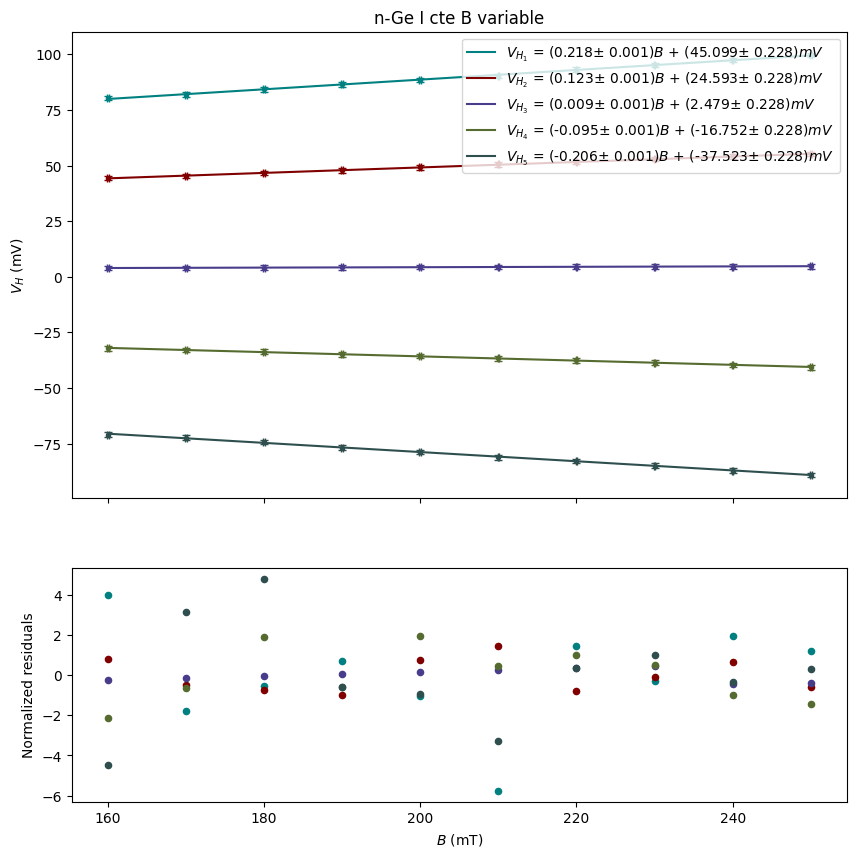

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex = True)
axes[0].errorbar(B1, V_H12, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="teal", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[0], c = 'teal', label = f'$V_{{H_1}}$ = ({slopes[0]:.3f}± {slope_errs[0]:.3f})$B$ + ({inters[0]:.3f}± {inter_errs[0]:.3f})$mV$')
axes[1].scatter(B1, norm_res[0], c = 'teal', label = 'Residuos toma 1', s = 20)

axes[0].errorbar(B1, V_H22, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="maroon", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[1], c = 'maroon', label = f'$V_{{H_2}}$ = ({slopes[1]:.3f}± {slope_errs[1]:.3f})$B$ + ({inters[1]:.3f}± {inter_errs[1]:.3f})$mV$')
axes[1].scatter(B1, norm_res[1], c = 'maroon', label = 'Residuos toma 2', s = 20)

axes[0].errorbar(B1, V_H32, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="darkslateblue", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[2], c = 'darkslateblue', label = f'$V_{{H_3}}$ = ({slopes[2]:.3f}± {slope_errs[2]:.3f})$B$ + ({inters[2]:.3f}± {inter_errs[2]:.3f})$mV$')
axes[1].scatter(B1, norm_res[2], c = 'darkslateblue', label = 'Residuos toma 3', s = 20)

axes[0].errorbar(B1, V_H42, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="darkolivegreen", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[3], c = 'darkolivegreen', label = f'$V_{{H_4}}$ = ({slopes[3]:.3f}± {slope_errs[3]:.3f})$B$ + ({inters[3]:.3f}± {inter_errs[3]:.3f})$mV$')
axes[1].scatter(B1, norm_res[3], c = 'darkolivegreen', label = 'Residuos toma 4', s = 20)

axes[0].errorbar(B1, V_H52, np.ones_like(B1), np.ones_like(V_H12)*0.1, c="darkslategray", fmt='o', capsize=3, ms = 3)
axes[0].plot(B1, y_preds[4], c = 'darkslategray', label = f'$V_{{H_5}}$ = ({slopes[4]:.3f}± {slope_errs[4]:.3f})$B$ + ({inters[4]:.3f}± {inter_errs[4]:.3f})$mV$')
axes[1].scatter(B1, norm_res[4], c = 'darkslategray', label = 'Residuos toma 5', s = 20)

axes[1].set_xlabel(r"$B$ (mT)")
axes[0].set_ylabel(r"$V_H$ (mV)")
axes[1].set_ylabel("Normalized residuals")
axes[0].legend(loc = 'upper right')
axes[0].set_title("n-Ge I cte B variable")

In [ ]:
import numpy as np

# Datos n-Ge
I_p = np.array([-30e-3, -15e-3, 0.0, 15e-3, 30e-3])       # A
s   = np.array([ 0.218,  0.123,  0.009, -0.095, -0.206])   # mV/mT = V/T
s_e = np.array([ 0.001,  0.001,  0.001,  0.001,  0.001])
c   = np.array([45.099, 24.593,  2.479, -16.752, -37.523]) # mV
c_e = np.array([ 0.228,  0.228,  0.228,  0.228,  0.228])

d = 1e-3       # m  ← AJUSTA al espesor real
q = 1.602e-19  # C

# R_H para cada I ≠ 0
mask = I_p != 0
R_H     = s[mask] * d / I_p[mask]
R_H_err = s_e[mask] * d / np.abs(I_p[mask])

print("I_p (mA) | R_H (m³/C)           | n (cm⁻³)")
print("-"*60)
for i, idx in enumerate(np.where(mask)[0]):
    n_i     = 1/(R_H[i]*q)
    n_i_err = np.abs(n_i) * (R_H_err[i]/np.abs(R_H[i]))
    print(f"{I_p[idx]*1e3:+6.1f}   | {R_H[i]:.4e} ± {R_H_err[i]:.0e} | "
          f"{n_i/1e6:.3e} ± {n_i_err/1e6:.0e}")

# Promedio ponderado
w = 1/R_H_err**2
R_H_avg = np.sum(R_H*w)/np.sum(w)
R_H_avg_err = np.sqrt(1/np.sum(w))
n_avg = 1/(R_H_avg*q)
n_avg_err = np.abs(n_avg) * (R_H_avg_err/np.abs(R_H_avg))

print(f"\nR_H promedio = {R_H_avg:.4e} ± {R_H_avg_err:.0e} m³/C")
print(f"n promedio   = {n_avg/1e6:.3e} ± {n_avg_err/1e6:.0e} cm⁻³")

I_p (mA) | R_H (m³/C)           | n (cm⁻³)
------------------------------------------------------------
 -30.0   | -7.2667e-03 ± 3e-05 | -8.590e+14 ± 4e+12
 -15.0   | -8.2000e-03 ± 7e-05 | -7.612e+14 ± 6e+12
 +15.0   | -6.3333e-03 ± 7e-05 | -9.856e+14 ± 1e+13
 +30.0   | -6.8667e-03 ± 3e-05 | -9.091e+14 ± 4e+12

R_H promedio = -7.1067e-03 ± 2e-05 m³/C
n promedio   = -8.784e+14 ± 3e+12 cm⁻³


# Actividad 3 P-Ge


In [ ]:
#B= np.array([])
I= np.array([0, 0.15, 0.30, 0.45, 0.6, 0.75,0.90, 1.05, 1.20, 1.35, 1.50]) #pasar esto a B de abajo (esto no es lo que necesitamos, necesitamos B)
#V_L= np.array([1.08, 1.08, 1.09, 1.09, 1.10, 1.10, 1.11, 1.11, 1.12, 1.12]) #V
V_L= np.array([0.994, 0.996, 0.998, 1, 1.003, 1.008, 1.012, 1.017, 1.022, 1.028, 1.033]) #V

In [ ]:
def B(I):
  return 194.3939393024902*(I) + 6.293333358227806
#B_err = 1 ó B_err = np.sqrt(194.3939393024902**2 * I_err)

In [ ]:
Ip = -30
R= V_L*1000/Ip
Vl_err = np.ones_like(V_L)*0.001
Ip_err = 1
R_err = np.sqrt((Vl_err/Ip)**2 + ((V_L*Ip_err)**2)/Ip**4)*1000
R0 = V_L[0]*1000/Ip
R0_err = R_err[0]
resis_norm = abs((R-R0)/R0)
resis_norm_err = np.sqrt((R_err/R0)**2 + (R*R0_err/R0**2)**2)

B = B(I)
I_err = 0.01
B_err = np.sqrt(194.3939393024902**2 * I_err**2)

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def modelo(B, a, b, e):
    return a * B**b + e

# Tus datos
B = B        # campo magnético (mT o T)
MR = resis_norm      # (Rm - R0)/R0
sigma_MR = resis_norm_err  # incertidumbre de cada punto de MR

# Valores iniciales razonables: a pequeño, b~2 (esperado teóricamente), e~0
p0 = [1e-6, 2, 0]

popt, pcov = curve_fit(
    modelo, B, MR,
    p0=p0,
    sigma=sigma_MR,
    absolute_sigma=True,
    maxfev=10000          # aumenta iteraciones si no converge de entrada
)

a, b, e = popt
sigma_a, sigma_b, sigma_e = np.sqrt(np.diag(pcov))

print(f"a = {a:.3e} ± {sigma_a:.1e}")
print(f"b = {b:.3f} ± {sigma_b:.3f}")
print(f"e = {e:.3e} ± {sigma_e:.1e}")

a = 4.601e-06 ± 1.2e-04
b = 1.590 ± 4.568
e = 1.728e-04 ± 3.5e-02


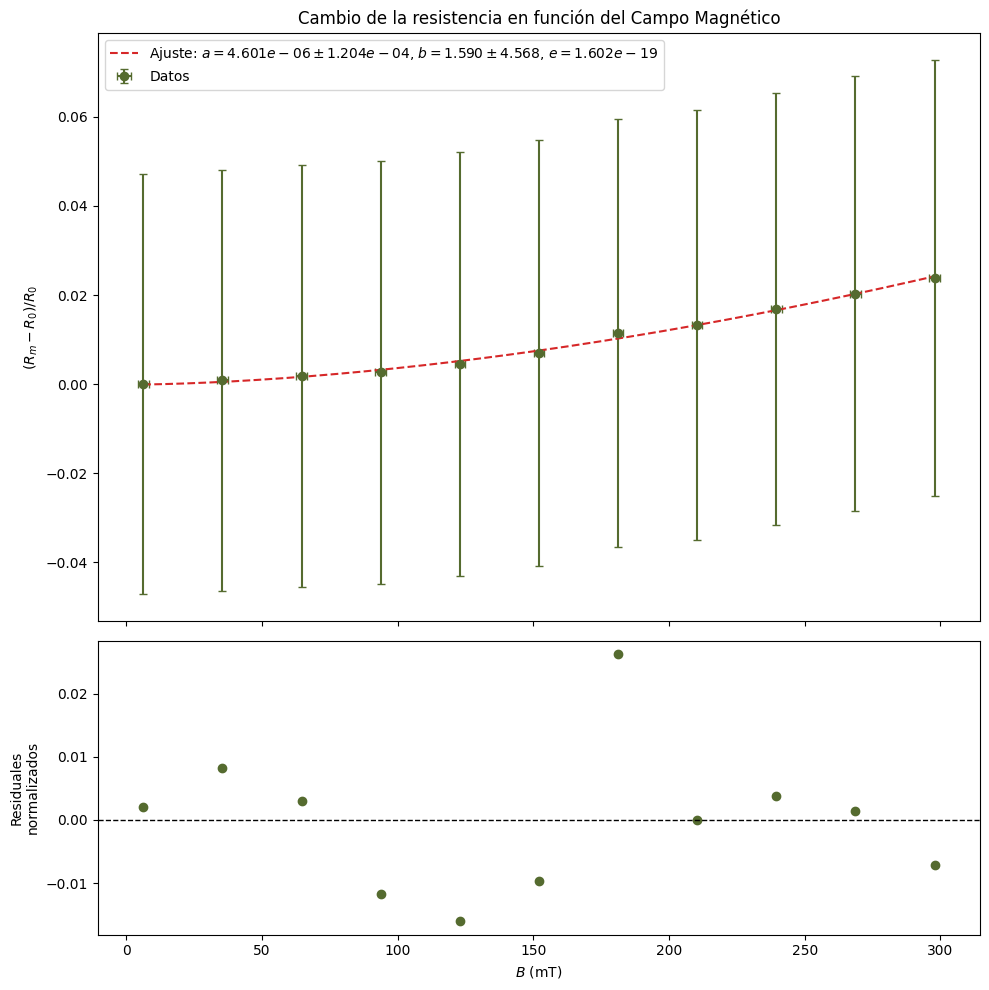

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,10), gridspec_kw={"height_ratios":[2,1]}, sharex=True)

B_fit = np.linspace(B.min(), B.max(), 300)
ax1.errorbar(B, MR, yerr=sigma_MR, xerr = B_err, fmt='o', capsize=3, label="Datos", c = 'darkolivegreen')
ax1.plot(B_fit, modelo(B_fit, *popt), '--', color='tab:red',
         label=fr"Ajuste: $a={a:.3e}\pm{sigma_a:.3e}$, $b={b:.3f}\pm{sigma_b:.3f}$, $e={e:.3e}$"  )
ax1.set_ylabel(r"$(R_m-R_0)/R_0$")
ax1.legend()
ax1.set_title("Cambio de la resistencia en función del Campo Magnético")

# Residuales normalizados
resid = (MR - modelo(B, *popt)) / sigma_MR
ax2.scatter(B, resid, color='darkolivegreen')
ax2.axhline(0, color='black', ls='--', lw=1)
ax2.set_xlabel(r"$B$ (mT)")
ax2.set_ylabel("Residuales\nnormalizados")

plt.tight_layout()
plt.show()

a = -4.1961e-06 ± 7.7648e-05
b = 1.5901 ± 3.2303
e = -1.9122e+00 ± 2.2716e-02


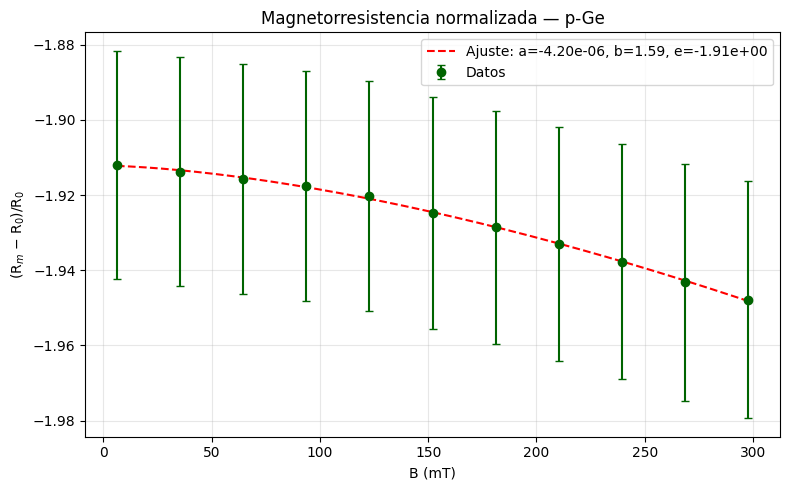

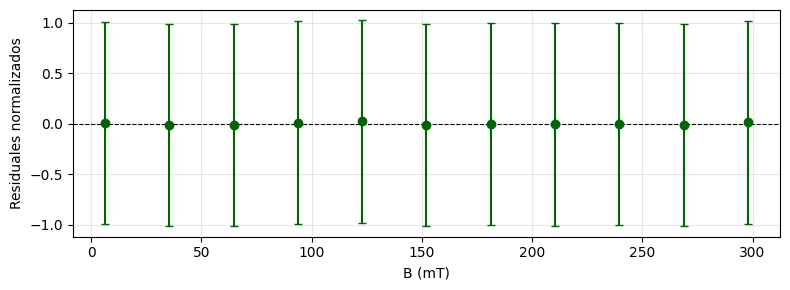

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Datos ---
I_bobina = np.array([0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.90,
                     1.05, 1.20, 1.35, 1.50])              # A
V_L = np.array([0.994, 0.996, 0.998, 1.000, 1.003, 1.008,
                1.012, 1.017, 1.022, 1.028, 1.033])         # V

Ip = -30e-3          # A  ← en SI
Ip_err = 1e-3        # A
V_L_err = 0.001      # V
I_bobina_err = 0.01  # A

# --- Calibración B(I) ---
def B_of_I(I):
    return 194.393939024902*I + 6.293333358227806   # mT

B = B_of_I(I_bobina)          # mT
B_err = 194.393939024902 * I_bobina_err  # mT

# --- Resistencia longitudinal ---
R = V_L / Ip                  # Ω  (Ip en A, V_L en V)
R_err = np.sqrt((V_L_err/Ip)**2 + (V_L*Ip_err/Ip**2)**2)

# --- R0 y su error ---
R0 = 36.33
R0_err = 0.01

# --- Magnetorresistencia normalizada ---
MR = (R - R0) / R0
MR_err = np.sqrt((R_err/R0)**2 + (R*R0_err/R0**2)**2)

# --- Ajuste ley de potencia: MR = a*B^b + e ---
def power_law(B, a, b, e):
    return a * B**b + e

p0 = [1e-6, 2, 0]
popt, pcov = curve_fit(power_law, B, MR, sigma=MR_err,
                       absolute_sigma=True, p0=p0, maxfev=20000)
perr = np.sqrt(np.diag(pcov))

print(f"a = {popt[0]:.4e} ± {perr[0]:.4e}")
print(f"b = {popt[1]:.4f} ± {perr[1]:.4f}")
print(f"e = {popt[2]:.4e} ± {perr[2]:.4e}")

# --- Gráfica ---
Bf = np.linspace(B.min(), B.max(), 200)
plt.figure(figsize=(8,5))
plt.errorbar(B, MR, yerr=MR_err, fmt='o', c='darkgreen',
             capsize=3, label='Datos')
plt.plot(Bf, power_law(Bf, *popt), 'r--',
         label=f'Ajuste: a={popt[0]:.2e}, b={popt[1]:.2f}, e={popt[2]:.2e}')
plt.xlabel('B (mT)')
plt.ylabel('(R$_m$ − R$_0$)/R$_0$')
plt.title('Magnetorresistencia normalizada — p-Ge')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Residuos normalizados ---
res = (MR - power_law(B, *popt)) / MR_err
plt.figure(figsize=(8,3))
plt.errorbar(B, res, yerr=1, fmt='o', c='darkgreen', capsize=3)
plt.axhline(0, color='k', ls='--', lw=0.8)
plt.xlabel('B (mT)')
plt.ylabel('Residuales normalizados')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Actividad 3 n-Ge

In [ ]:
#B= np.array([])
I= np.array([0, 0.15, 0.30, 0.45, 0.6, 0.75, 0.90, 1.05, 1.20, 1.35, 1.50]) #pasar esto a B de abajo (esto no es lo que necesitamos, necesitamos B)
V_L= np.array([1.132, 1.133, 1.134, 1.135, 1.137, 1.140, 1.145, 1.147, 1.151, 1.155, 1.159]) #V

In [ ]:
def B(I):
  return 194.3939393024902*(I) + 6.293333358227806

In [ ]:
Ip = -30
R= V_L*1000/Ip
Vl_err = np.ones_like(V_L)*0.001
Ip_err = 1
R_err = np.sqrt((Vl_err/Ip)**2 + ((V_L*Ip_err)**2)/Ip**4)*1000
R0 = V_L[0]*1000/Ip
R0_err = R_err[0]
resis_norm = abs((R-R0)/R0)
resis_norm_err = np.sqrt((R_err/R0)**2 + (R*R0_err/R0**2)**2)

B = B(I)
I_err = 0.01
B_err = np.sqrt(194.3939393024902**2 * I_err**2)

R0 = 37.733 ± 1.258 Ω
a = 1.3534e-06 ± 6.0802e-05
b = 1.7198 ± 7.8575
e = -1.3023e-04 ± 3.3460e-02


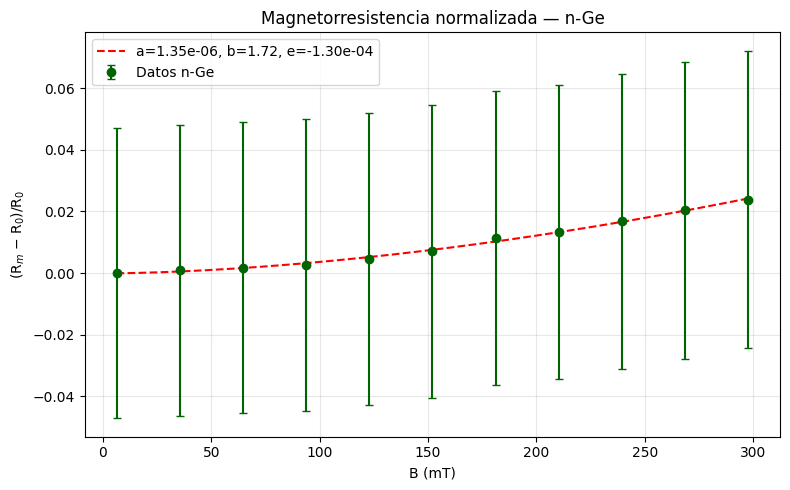

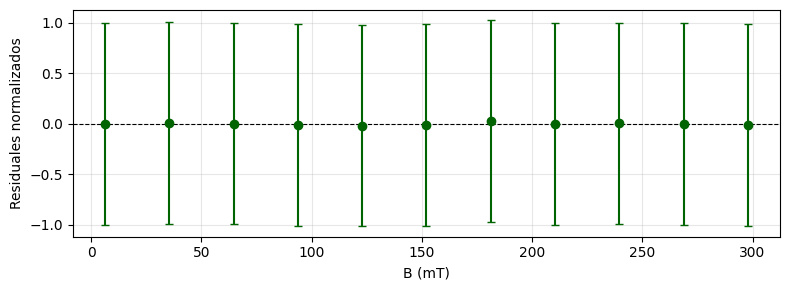

σ0 = 53.00 ± 1.77 S/m
ρ0 = 0.0189 Ω·m


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Datos n-Ge ---
I_bobina = np.array([0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.90,
                     1.05, 1.20, 1.35, 1.50])                # A
V_L = np.array([1.132, 1.133, 1.134, 1.135, 1.137, 1.140,
                1.145, 1.147, 1.151, 1.155, 1.159])          # V

Ip      = 30e-3      # A  ← toma |Ip| para R positiva
Ip_err  = 1e-3       # A
V_L_err = 0.001      # V
I_err   = 0.01       # A

# --- Calibración B(I) ---
def B_of_I(I):
    return 194.393939024902*I + 6.293333358227806   # mT

B     = B_of_I(I_bobina)
B_err = 194.393939024902 * I_err

# --- Resistencia longitudinal ---
R     = V_L / Ip
R_err = np.sqrt((V_L_err/Ip)**2 + (V_L*Ip_err/Ip**2)**2)

# --- R0 (usa el primer punto, B = 6.3 mT) ---
R0     = R[0]
R0_err = R_err[0]

# --- Magnetorresistencia normalizada ---
MR     = (R - R0) / R0
MR_err = np.sqrt((R_err/R0)**2 + (R*R0_err/R0**2)**2)

# --- Ajuste ley de potencia: MR = a*B^b + e ---
def power_law(B, a, b, e):
    return a * B**b + e

p0   = [1e-6, 2, 0]
popt, pcov = curve_fit(power_law, B, MR, sigma=MR_err,
                       absolute_sigma=True, p0=p0, maxfev=20000)
perr = np.sqrt(np.diag(pcov))

print(f"R0 = {R0:.3f} ± {R0_err:.3f} Ω")
print(f"a = {popt[0]:.4e} ± {perr[0]:.4e}")
print(f"b = {popt[1]:.4f} ± {perr[1]:.4f}")
print(f"e = {popt[2]:.4e} ± {perr[2]:.4e}")

# --- Gráfica ---
Bf = np.linspace(B.min(), B.max(), 200)
plt.figure(figsize=(8,5))
plt.errorbar(B, MR, yerr=MR_err, fmt='o', c='darkgreen',
             capsize=3, label='Datos n-Ge')
plt.plot(Bf, power_law(Bf, *popt), 'r--',
         label=f'a={popt[0]:.2e}, b={popt[1]:.2f}, e={popt[2]:.2e}')
plt.xlabel('B (mT)')
plt.ylabel('(R$_m$ − R$_0$)/R$_0$')
plt.title('Magnetorresistencia normalizada — n-Ge')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# --- Residuos normalizados ---
res = (MR - power_law(B, *popt)) / MR_err
plt.figure(figsize=(8,3))
plt.errorbar(B, res, yerr=1, fmt='o', c='darkgreen', capsize=3)
plt.axhline(0, color='k', ls='--', lw=0.8)
plt.xlabel('B (mT)'); plt.ylabel('Residuales normalizados')
plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# --- Conductividad a B = 0 ---
L = 20e-3; w = 10e-3; d = 1e-3
A = w * d
sigma_0     = L * Ip / (V_L[0] * A)
sigma_0_err = sigma_0 * np.sqrt((V_L_err/V_L[0])**2 + (Ip_err/Ip)**2)
print(f"σ0 = {sigma_0:.2f} ± {sigma_0_err:.2f} S/m")
print(f"ρ0 = {1/sigma_0:.4f} Ω·m")

# Conductividad

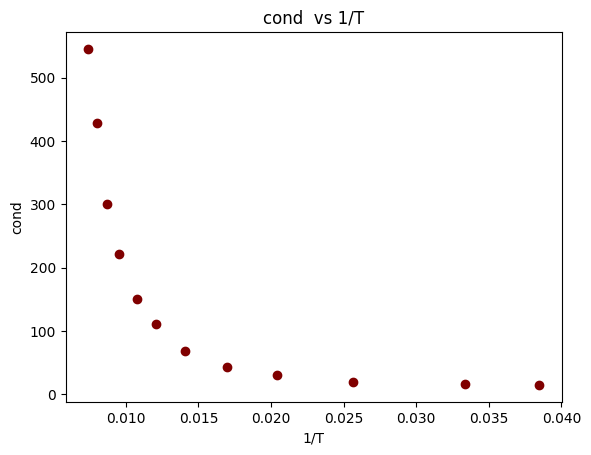

In [ ]:
#placa intrinseca
T = np.array([26, 30, 39, 49, 59, 71, 83, 93, 105, 115, 125, 135])
Vl = np.array([-3.99, -3.74, -2.94, -2, -1.39, -0.87, -0.54, -0.4, -0.27, -0.2, -0.14, -0.11])
L = 20e-3   # m (longitud, dirección de la corriente y de V_L)
w = 10e-3   # m (ancho, dirección transversal donde se mide V_H)
d = 1e-3    # m (espesor, dirección del campo B)
A = w * d
Ip = 30/1000
cond = L*Ip/(A*-Vl)


plt.scatter(1/T, cond, c="maroon")
plt.xlabel("1/T")
plt.ylabel("cond")
plt.title("cond  vs 1/T")
plt.savefig("VhvsT_intrin", dpi = 300)

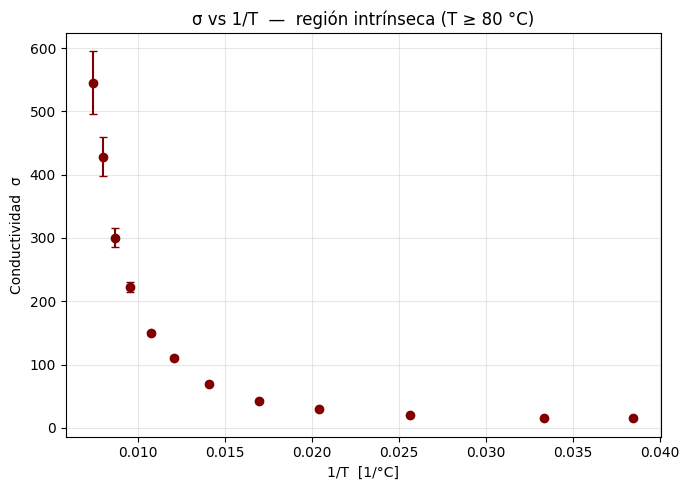

In [ ]:
# Original T and Vl from cell 2eZFB2GbAOv8 for "placa intrinseca"
T_intrinsic = np.array([26, 30, 39, 49, 59, 71, 83, 93, 105, 115, 125, 135])
Vl_intrinsic = np.array([-3.99, -3.74, -2.94, -2, -1.39, -0.87, -0.54, -0.4, -0.27, -0.2, -0.14, -0.11])

T_cut    = T_intrinsic
V_Lp_cut = Vl_intrinsic
V_err    = np.full_like(V_Lp_cut, 0.01, dtype=float)

# Conductividad (positiva, con signo corregido)
cond     = L * Ip / (A * np.abs(V_Lp_cut))
# Error propagado: ∂cond/∂V_Lp = -L·Ip/(A·V_Lp²)
cond_err = L * Ip / (A * V_Lp_cut**2) * V_err

# Gráfica
plt.figure(figsize=(7,5))
plt.errorbar(1/T_cut, cond, yerr=cond_err, fmt='o',
             c='maroon', capsize=3)
plt.xlabel('1/T  [1/°C]')
plt.ylabel('Conductividad  σ')
plt.title('σ vs 1/T  —  región intrínseca (T ≥ 80 °C)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Slope (a): -3344.558549282903 ± 12.526159198461178
Intercept (b): 13.828094851847686 ± 0.0407760884193214
Residuals: [ 25.00302645  -7.53632407 -28.68621947  -8.98120176   0.88516027
  10.77304141  14.75854603  12.67739803  11.34301825   9.84705398
   8.85654119   7.34755327]


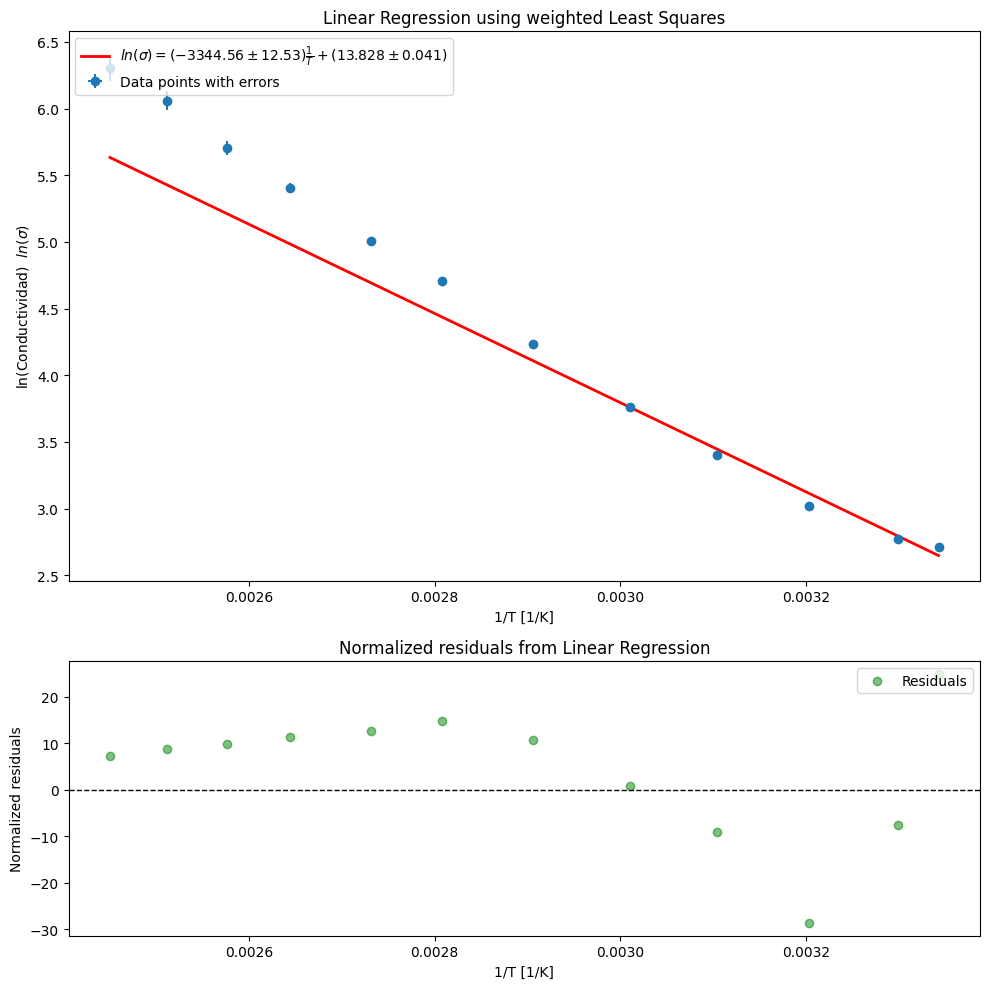

In [ ]:
T_K = T_cut + 273.15
x   = 1/T_K
y   = np.log(cond)
yerr = cond_err / cond   # propagación: σ_ln(σ) = σ_σ / σ
xerr = np.zeros_like(x)

# Calculate weights
weights = 1 / yerr**2

# Calculate sums needed for slope and intercept
sum_w = weights.sum()
sum_wx = (weights * x).sum()
sum_wy = (weights * y).sum()
sum_wxx = (weights * x**2).sum()
sum_wxy = (weights * x * y).sum()

# Calculate weighted slope (a) and intercept (b)
slope = (sum_w * sum_wxy - sum_wx * sum_wy) / (sum_w * sum_wxx - sum_wx**2)
intercept = (sum_wxx * sum_wy - sum_wx * sum_wxy) / (sum_w * sum_wxx - sum_wx**2)

# Calculate standard errors (uncertainties)
slope_std_err = np.sqrt(sum_w / (sum_w * sum_wxx - sum_wx**2))
intercept_std_err = np.sqrt(sum_wxx / (sum_w * sum_wxx - sum_wx**2))

# Predict the Y values
y_pred = slope * x + intercept

# Calculate normalized residuals
residuals = (y - y_pred)/yerr


print(f"Slope (a): {slope} ± {slope_std_err}")
print(f"Intercept (b): {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})  # 2 rows, 1 column, width = 10 inches, height = 10 inches

# Plot the regression line
ax1.errorbar(x, y, yerr, xerr,  fmt='o', label='Data points with errors')
ax1.plot(x, y_pred, color='red', linewidth=2, label=rf'$ln(\sigma) = ({slope:.2f}\pm{slope_std_err:.2f})\frac{{1}}{{T}} + ({intercept:.3f}\pm{intercept_std_err:.3f})$')

ax1.set_xlabel('1/T [1/K]')
ax1.set_ylabel(r'ln(Conductividad)  $ln(\sigma)$')
ax1.legend(loc='upper left')
ax1.set_title('Linear Regression using weighted Least Squares')

# Plot normalized residuals
ax2.scatter(x, residuals, color='green', alpha=0.5, label='Residuals')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('1/T [1/K]')
ax2.set_ylabel('Normalized residuals')
ax2.legend(loc='upper right')
ax2.set_title('Normalized residuals from Linear Regression')

plt.tight_layout()

# Save the figure as a PDF file
plt.show()

In [ ]:
Kb = 1.380649e-23
e = 1.602176634e-19
Eg = (-slope * Kb)/e
Eg_err = (Kb*slope_std_err)/e
print(f"Eg = {Eg:.3f} ± {Eg_err:.3f} eV")

Eg = 0.288 ± 0.001 eV


cond placa p-Ge

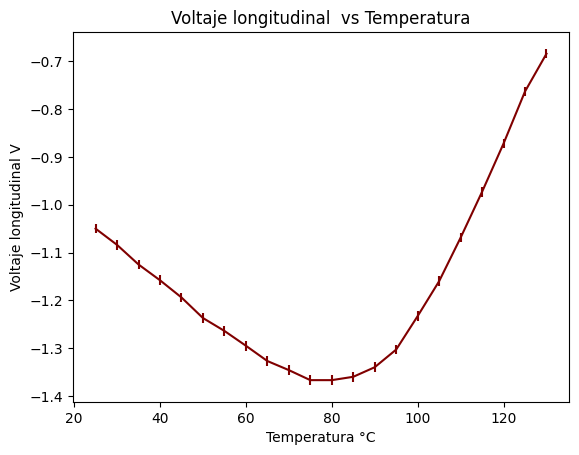

In [ ]:
#para p-Ge
#Ip = 30mA
T= np.array([25, 30,   35,    40,     45,   50,     55,   60,    65,     70,    75,    80,    85,    90,    95,   100,   105,   110,   115,   120,    125,   130])
V_Lp= np.array([-1.05, -1.084, -1.125, -1.158, -1.194, -1.237, -1.264, -1.295, -1.327, -1.346, -1.367, -1.367, -1.36, -1.34, -1.303, -1.233, -1.16, -1.069, -0.973, -0.872, -0.763, -0.684]) #mV
Terr = np.ones_like(T)
V_Lp_err = np.ones_like(V_Lp)*0.01

plt.errorbar(T, V_Lp, yerr = V_Lp_err,c="maroon")
plt.xlabel("Temperatura °C")
plt.ylabel("Voltaje longitudinal V")
plt.title("Voltaje longitudinal  vs Temperatura")
plt.savefig("VhvsT_p_Ge", dpi = 300)

In [ ]:
#hallar  σ0 = L/R0*A,

In [ ]:
L = 20e-3   # m (longitud, dirección de la corriente y de V_L)
w = 10e-3   # m (ancho, dirección transversal donde se mide V_H)
d = 1e-3    # m (espesor, dirección del campo B)
A = w * d
Ip = 30/1000
cond_0 = L/(R0*A)
cond_0_err = np.sqrt((L*R0_err / (R0**2 * A))**2)

cond = L*Ip/(A*-V_Lp)

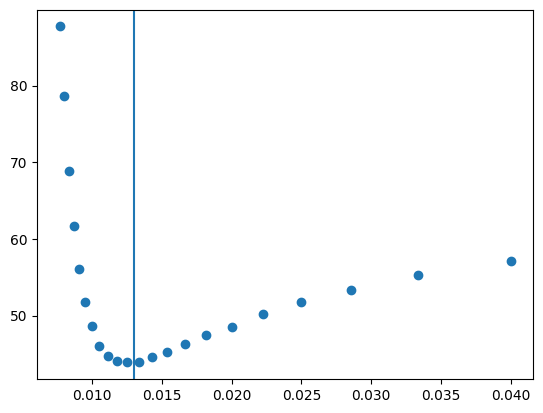

In [ ]:
plt.scatter(1/T, cond)
plt.axvline(x=0.013)

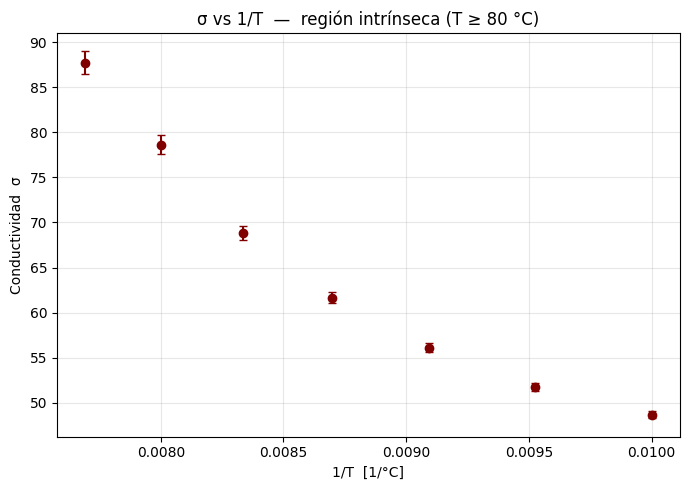

In [ ]:
mask = T >= 100
T_cut    = T[mask]
V_Lp_cut = V_Lp[mask]
V_err    = np.full_like(V_Lp_cut, 0.01, dtype=float)

# Conductividad (positiva, con signo corregido)
cond     = L * Ip / (A * np.abs(V_Lp_cut))
# Error propagado: ∂cond/∂V_Lp = -L·Ip/(A·V_Lp²)
cond_err = L * Ip / (A * V_Lp_cut**2) * V_err

# Gráfica
plt.figure(figsize=(7,5))
plt.errorbar(1/T_cut, cond, yerr=cond_err, fmt='o',
             c='maroon', capsize=3)
plt.xlabel('1/T  [1/°C]')
plt.ylabel('Conductividad  σ')
plt.title('σ vs 1/T  —  región intrínseca (T ≥ 80 °C)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

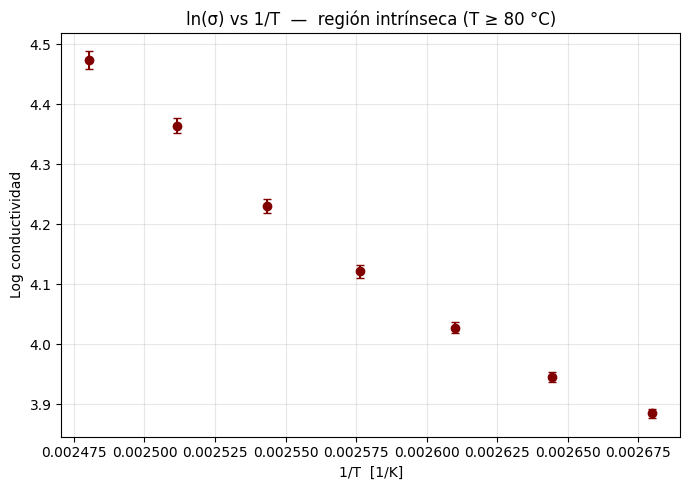

In [ ]:
plt.figure(figsize=(7,5))
plt.errorbar(1/(T_cut+273.15), np.log(cond), yerr=cond_err/cond, fmt='o',
             c='maroon', capsize=3)
plt.xlabel('1/T  [1/K]')
plt.ylabel('Log conductividad')
plt.title('ln(σ) vs 1/T  —  región intrínseca (T ≥ 80 °C)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#ln(cond) va lineal con 1/T

Slope (a): -2869.9141062584995 ± 61.31222418070776
Intercept (b): 11.545480585854351 ± 0.15963860432900054
Residuals: [ 3.75578372 -1.18346872 -2.94454768 -2.91291139 -1.25358079  2.09703361
  3.24124629]


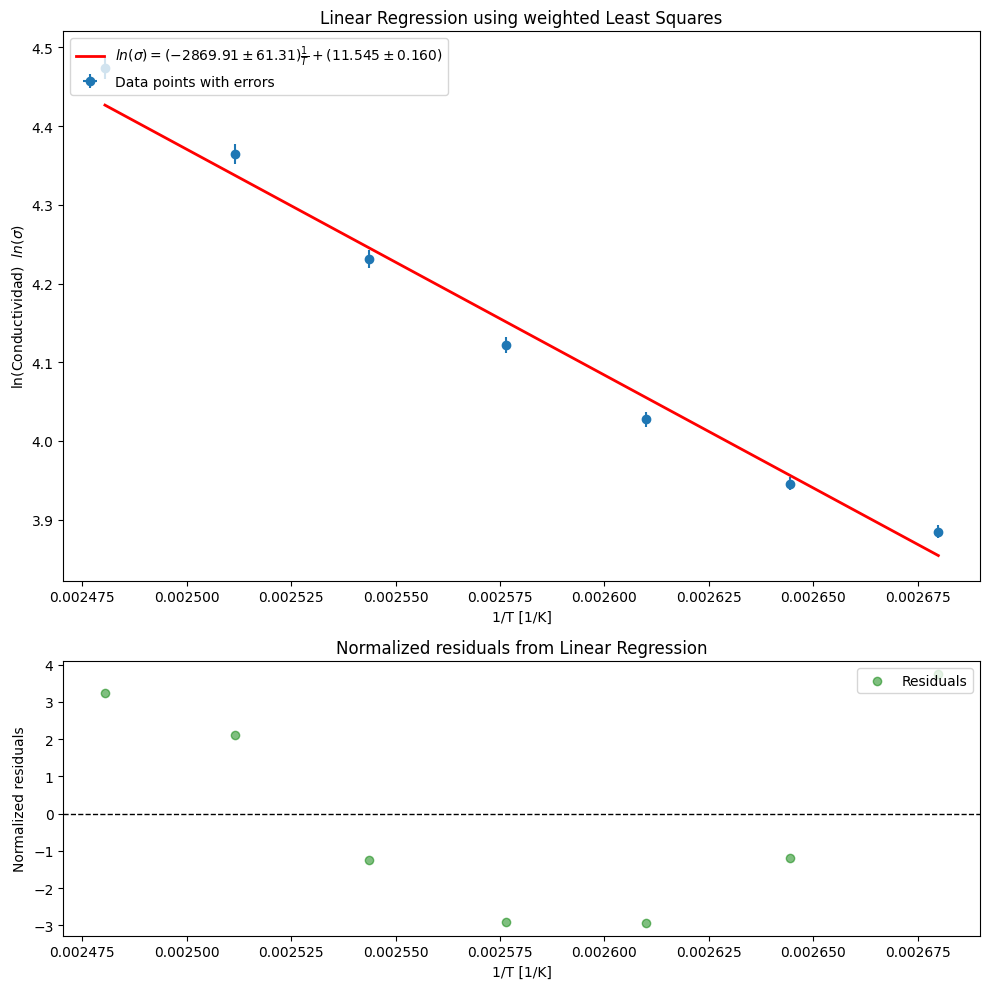

In [ ]:
T_K = T_cut + 273.15
x   = 1/T_K
y   = np.log(cond)
yerr = cond_err / cond   # propagación: σ_ln(σ) = σ_σ / σ
xerr = np.zeros_like(x)

# Calculate weights
weights = 1 / yerr**2

# Calculate sums needed for slope and intercept
sum_w = weights.sum()
sum_wx = (weights * x).sum()
sum_wy = (weights * y).sum()
sum_wxx = (weights * x**2).sum()
sum_wxy = (weights * x * y).sum()

# Calculate weighted slope (a) and intercept (b)
slope = (sum_w * sum_wxy - sum_wx * sum_wy) / (sum_w * sum_wxx - sum_wx**2)
intercept = (sum_wxx * sum_wy - sum_wx * sum_wxy) / (sum_w * sum_wxx - sum_wx**2)

# Calculate standard errors (uncertainties)
slope_std_err = np.sqrt(sum_w / (sum_w * sum_wxx - sum_wx**2))
intercept_std_err = np.sqrt(sum_wxx / (sum_w * sum_wxx - sum_wx**2))

# Predict the Y values
y_pred = slope * x + intercept

# Calculate normalized residuals
residuals = (y - y_pred)/yerr


print(f"Slope (a): {slope} ± {slope_std_err}")
print(f"Intercept (b): {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})  # 2 rows, 1 column, width = 10 inches, height = 10 inches

# Plot the regression line
ax1.errorbar(x, y, yerr, xerr,  fmt='o', label='Data points with errors')
ax1.plot(x, y_pred, color='red', linewidth=2, label=rf'$ln(\sigma) = ({slope:.2f}\pm{slope_std_err:.2f})\frac{{1}}{{T}} + ({intercept:.3f}\pm{intercept_std_err:.3f})$')

ax1.set_xlabel('1/T [1/K]')
ax1.set_ylabel(r'ln(Conductividad)  $ln(\sigma)$')
ax1.legend(loc='upper left')
ax1.set_title('Linear Regression using weighted Least Squares')

# Plot normalized residuals
ax2.scatter(x, residuals, color='green', alpha=0.5, label='Residuals')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('1/T [1/K]')
ax2.set_ylabel('Normalized residuals')
ax2.legend(loc='upper right')
ax2.set_title('Normalized residuals from Linear Regression')

plt.tight_layout()

# Save the figure as a PDF file
plt.show()

In [ ]:
Kb = 1.380649e-23
e = 1.602176634e-19
Eg = (-slope * Kb)/e
Eg_err = (Kb*slope_std_err)/e
print(f"Eg = {Eg:.3f} ± {Eg_err:.3f} eV")

Eg = 0.247 ± 0.005 eV


placa n-Ge conductividad

In [ ]:
#para n-Ge
T= np.array([30,   35,    40,     45,   50,     55,   60,    65,     70,    75,    80,    85,    90,    95,   100,   105,   110,   115,   120])
V_Lp= np.array([-1.124, -1.154, -1.18, -1.2, -1.222, -1.241, -1.253, -1.257, -1.25, -1.233, -1.192, -1.142, -1.085, -1.006, -0.927, -0.846, -0.767, -0.698, -0.62]) #V

cond = L*Ip/(A*-V_Lp)

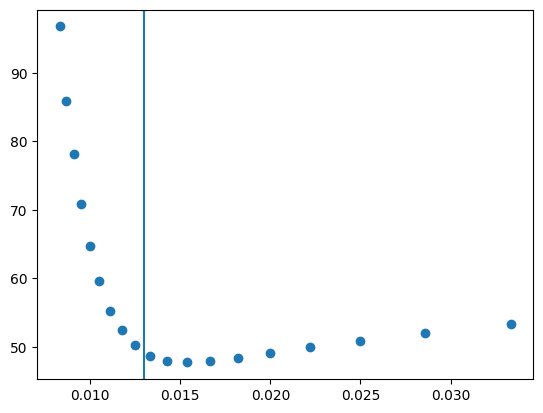

In [ ]:
plt.scatter(1/T, cond)
plt.axvline(x=0.013)

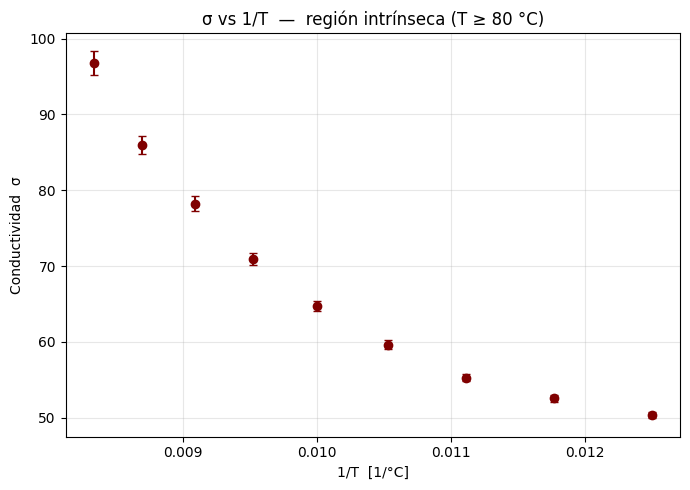

In [ ]:
mask = T >= 80
T_cut    = T[mask]
V_Lp_cut = V_Lp[mask]
V_err    = np.full_like(V_Lp_cut, 0.01, dtype=float)

# Conductividad (positiva, con signo corregido)
cond     = L * Ip / (A * np.abs(V_Lp_cut))
# Error propagado: ∂cond/∂V_Lp = -L·Ip/(A·V_Lp²)
cond_err = L * Ip / (A * V_Lp_cut**2) * V_err

# Gráfica
plt.figure(figsize=(7,5))
plt.errorbar(1/T_cut, cond, yerr=cond_err, fmt='o',
             c='maroon', capsize=3)
plt.xlabel('1/T  [1/°C]')
plt.ylabel('Conductividad  σ')
plt.title('σ vs 1/T  —  región intrínseca (T ≥ 80 °C)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Slope (a): -2148.85917577218 ± 40.66745149564746
Intercept (b): 9.960580102774703 ± 0.11065952561748252
Residuals: [ 5.12155061  0.09928112 -3.31342031 -3.55173831 -2.94165851 -1.39099067
  0.57024956  2.05611352  4.80804727]


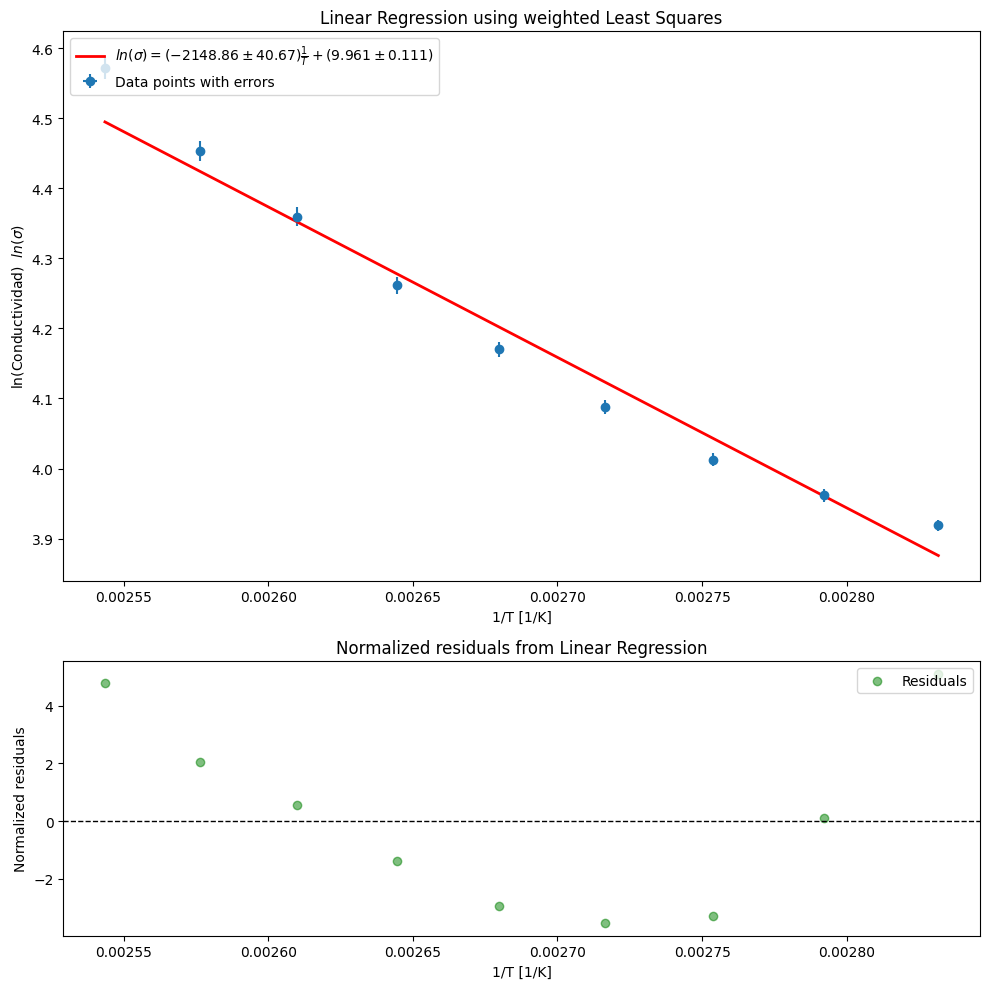

In [ ]:
T_K = T_cut + 273.15
x   = 1/T_K
y   = np.log(cond)
yerr = cond_err / cond   # propagación: σ_ln(σ) = σ_σ / σ
xerr = np.zeros_like(x)

# Calculate weights
weights = 1 / yerr**2

# Calculate sums needed for slope and intercept
sum_w = weights.sum()
sum_wx = (weights * x).sum()
sum_wy = (weights * y).sum()
sum_wxx = (weights * x**2).sum()
sum_wxy = (weights * x * y).sum()

# Calculate weighted slope (a) and intercept (b)
slope = (sum_w * sum_wxy - sum_wx * sum_wy) / (sum_w * sum_wxx - sum_wx**2)
intercept = (sum_wxx * sum_wy - sum_wx * sum_wxy) / (sum_w * sum_wxx - sum_wx**2)

# Calculate standard errors (uncertainties)
slope_std_err = np.sqrt(sum_w / (sum_w * sum_wxx - sum_wx**2))
intercept_std_err = np.sqrt(sum_wxx / (sum_w * sum_wxx - sum_wx**2))

# Predict the Y values
y_pred = slope * x + intercept

# Calculate normalized residuals
residuals = (y - y_pred)/yerr


print(f"Slope (a): {slope} ± {slope_std_err}")
print(f"Intercept (b): {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})  # 2 rows, 1 column, width = 10 inches, height = 10 inches

# Plot the regression line
ax1.errorbar(x, y, yerr, xerr,  fmt='o', label='Data points with errors')
ax1.plot(x, y_pred, color='red', linewidth=2, label=rf'$ln(\sigma) = ({slope:.2f}\pm{slope_std_err:.2f})\frac{{1}}{{T}} + ({intercept:.3f}\pm{intercept_std_err:.3f})$')

ax1.set_xlabel('1/T [1/K]')
ax1.set_ylabel(r'ln(Conductividad)  $ln(\sigma)$')
ax1.legend(loc='upper left')
ax1.set_title('Linear Regression using weighted Least Squares')

# Plot normalized residuals
ax2.scatter(x, residuals, color='green', alpha=0.5, label='Residuals')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('1/T [1/K]')
ax2.set_ylabel('Normalized residuals')
ax2.legend(loc='upper right')
ax2.set_title('Normalized residuals from Linear Regression')

plt.tight_layout()

# Save the figure as a PDF file
plt.show()

In [ ]:
Kb = 1.380649e-23
e = 1.602176634e-19
Eg = (-slope * Kb)/e
Eg_err = (Kb*slope_std_err)/e
print(f"Eg = {Eg:.3f} ± {Eg_err:.3f} eV")

Eg = 0.185 ± 0.004 eV


Ejercicio 2

In [ ]:
w= 1e-3
Ip= 30 #mA
Bz= 300 #mT
R_H= (V_Hp*w)/(Ip*Bz)

plt.scatter(T, R_H, c="green")
plt.xlabel("Temperatura °C")
plt.ylabel("Coeficiente de Hall")
plt.title("Temperatura vs R_H   p-Ge")

NameError: name 'V_Hp' is not defined

Ejercicio 3


In [ ]:
#plt.scatter(1/T, R_H*(T**(3/2)))
#plt.xlabel("1/T")
#plt.ylabel("R_H*T^3/2")
#plt.title("R_H*T^3/2 vs 1/T")
errorA= 0.1*np.ones_like(R_H) #Verificar/corregir
errorC= 0.01* np.ones_like(T) #verificar/corregir

def linear_function(X, a, b):
    return a * X + b

x1= R_H*(T**(3/2))
y1= 1/T
errorx1= errorA
errory1=errorC
popt, pcov = curve_fit(
    linear_function,
    x1,
    y1,
    sigma=errorx1,
    absolute_sigma=True
)
slope = popt[0]
intercept = popt[1]
slope_std_err = np.sqrt(pcov[0, 0])
intercept_std_err = np.sqrt(pcov[1, 1])
yerr = errorx1
xerr = errory1
Y_pred = linear_function(x1, *popt)
residuals = (y1 - Y_pred) / yerr


print(f"Slope: {slope} ± {slope_std_err}")
print(f"Intercept: {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")


# =====================================
# MAIN FIGURE
# =====================================

fig, ax1 = plt.subplots(figsize=(10, 7))

ax1.errorbar(
    x1,
    y1,
    yerr=yerr,
    xerr=xerr,
    fmt='o',
    c="darkslateblue",
    label='Datos experimentales con error asociado',
    capsize=3
)

ax1.plot(
    x1,
    Y_pred,
    color='lightsalmon',
    linewidth=2,
    label=(
        f'Regresión Lineal: '
        f'Ω= ({slope:.1f}±{slope_std_err:.1f})B + '
        f'({intercept:.2f}±{intercept_std_err:.2f})'
    )
)
ax1.set_xlabel(r'1/T')
ax1.set_ylabel(r'R_H*T^3/2')

ax1.set_title(
    'R_H*T^3/2 vs 1/T'
)

ax1.legend(loc='upper left')


# =====================================
# RESIDUALS INSET
# =====================================

ax_res = ax1.inset_axes(
    [0.60, 0.12, 0.36, 0.30]
)
ax_res.scatter(
    x1,
    residuals,
    color='sienna',
    s=50
)
ax_res.axhline(
    0,
    color='grey',
    linewidth=1,
    linestyle='--'
)



ax_res.set_title(
    'Residuos normalizados',
    fontsize=11
)

ax_res.set_xlabel(
    r'1/T',
    fontsize=9
)

ax_res.set_ylabel(
    r'Residuos',
    fontsize=9
)

ax_res.tick_params(
    axis='both',
    labelsize=8
)

ax_res.grid(
    True,
    alpha=0.4
)

plt.tight_layout()
plt.show()

para n-Ge

In [ ]:
V

conductividad placa intrinseca

In [ ]:
T = np.array([26, 30, 39, 49, 59, 71, 83, 93, 105, 115, 125, 135])
Vl = np.array([-3.99, -3.74, -2.94, -2, -1.39, -0.87, -0.54, -0.4, -0.27, -0.2, -0.14, -0.11])

In [ ]:
plt.scatter(1/T, Vl, c="maroon")
plt.xlabel("Temperatura °C")
plt.ylabel("Voltaje longitudinal V")
plt.title("Voltaje longitudinal  vs Temperatura")
plt.savefig("VhvsT_intrin", dpi = 300)